In [1]:
# ============================================================
# 0. Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/paper1-reproduction-2022-2"

Mounted at /content/drive
/content/drive/MyDrive/paper1-reproduction-2022-2


In [2]:
# ============================================================
# 1. Imports / Seed
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [3]:
# ============================================================
# 2. Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/paper1-reproduction-2022-2"

DATA_PATH = (
    "/content/drive/MyDrive/"
    "xai - article/data/raw/heat_Data.csv"
)

RESULT_DIR = f"{PROJECT_DIR}/results/random_split"
MODEL_DIR = f"{PROJECT_DIR}/models/random_split"

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [4]:
# ============================================================
# 3. Load
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    encoding="cp949",
    low_memory=False
)

print(df.shape)
df.head()

(103913, 11)


,일자,시간,생산항목코드,열공급시설ID,난방지역ID,공급유량,공급열량,공급압력,공급온도,회수압력,회수온도
0,2023-07-07,1,열,중앙열공급시설,여의도,52,2,5,84,3,57
1,2023-07-07,1,열,강남열공급시설,송파/잠실,0,56,0,0,0,0
2,2023-07-07,1,열,수서열공급시설,강남/서초,0,6,0,0,0,0
3,2023-07-07,1,열,동남권열공급시설,동남권,0,0,0,0,0,0
4,2023-07-07,1,열,상암열공급시설,상암,99,6,3,96,2,44


In [5]:
# ============================================================
# 4. Sangam selection
# ============================================================

sangam = df[
    (df["열공급시설ID"] == "상암열공급시설") &
    (df["난방지역ID"] == "상암")
].copy()

print(sangam.shape)

(4497, 11)


In [6]:
# ============================================================
# 5. Rename
# ============================================================

sangam = sangam.rename(columns={
    "일자": "date",
    "시간": "hour_raw",

    "공급유량": "flow",
    "공급열량": "heat",

    "공급압력": "supply_pressure",
    "공급온도": "supply_temp",

    "회수압력": "return_pressure",
    "회수온도": "return_temp"
})

In [7]:
# ============================================================
# 6. Datetime
# ============================================================

sangam["datetime"] = (
    pd.to_datetime(sangam["date"])
    + pd.to_timedelta(
        sangam["hour_raw"] - 1,
        unit="h"
    )
)

sangam = (
    sangam
    .sort_values("datetime")
    .reset_index(drop=True)
)

print(sangam["datetime"].min())
print(sangam["datetime"].max())

2023-01-01 00:00:00
2023-07-07 08:00:00


In [8]:
# ============================================================
# 7. Numeric conversion
# ============================================================

numeric_cols = [
    "flow",
    "heat",
    "supply_pressure",
    "supply_temp",
    "return_pressure",
    "return_temp"
]

for col in numeric_cols:
    sangam[col] = pd.to_numeric(
        sangam[col],
        errors="coerce"
    )

print(sangam[numeric_cols].isna().sum())

flow               121
heat                10
supply_pressure      0
supply_temp        119
return_pressure      0
return_temp          0
dtype: int64


In [9]:
# ============================================================
# 8. Heat extreme outlier removal
# ============================================================

heat_median = sangam["heat"].median()

heat_mad = (
    sangam["heat"] - heat_median
).abs().median()

if heat_mad > 0:

    lower = heat_median - 10 * heat_mad
    upper = heat_median + 10 * heat_mad

    outlier_mask = (
        (sangam["heat"] < lower) |
        (sangam["heat"] > upper)
    )

    print("Outliers:", outlier_mask.sum())

    sangam.loc[
        outlier_mask,
        "heat"
    ] = np.nan

Outliers: 1


In [10]:
# ============================================================
# 9. Missing-value interpolation
# ============================================================

sangam[numeric_cols] = (
    sangam[numeric_cols]
    .interpolate(
        method="linear",
        limit_direction="both"
    )
)

print(sangam[numeric_cols].isna().sum())

flow               0
heat               0
supply_pressure    0
supply_temp        0
return_pressure    0
return_temp        0
dtype: int64


In [12]:
# ============================================================
# 10. Baseline dataframe
# ============================================================

baseline_df = sangam[
    [
        "datetime",
        "flow",
        "heat",
        "supply_pressure",
        "supply_temp",
        "return_pressure",
        "return_temp"
    ]
].copy()

baseline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4497 entries, 0 to 4496
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         4497 non-null   datetime64[ns]
 1   flow             4497 non-null   float64       
 2   heat             4497 non-null   float64       
 3   supply_pressure  4497 non-null   int64         
 4   supply_temp      4497 non-null   float64       
 5   return_pressure  4497 non-null   int64         
 6   return_temp      4497 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 246.1 KB


In [13]:
# ============================================================
# 11. Paper 1 features
# ============================================================

p1_df = baseline_df.copy()

p1_df["year"] = p1_df["datetime"].dt.year
p1_df["month"] = p1_df["datetime"].dt.month
p1_df["day"] = p1_df["datetime"].dt.day
p1_df["hour"] = p1_df["datetime"].dt.hour

# Our explicit E-Diff definition
p1_df["e_diff"] = p1_df["heat"].diff()
p1_df["e_diff"] = p1_df["e_diff"].fillna(1e-6)

In [14]:
# ============================================================
# 12. Feature definitions
# ============================================================

FEATURE_COLS = [
    "year",
    "month",
    "day",
    "hour",
    "e_diff",
    "flow",
    "supply_pressure",
    "supply_temp",
    "return_pressure",
    "return_temp"
]

TARGET_COL = "heat"

EPS = 1e-6

p1_df[FEATURE_COLS] = (
    p1_df[FEATURE_COLS]
    .replace(0, EPS)
)

print(FEATURE_COLS)

['year', 'month', 'day', 'hour', 'e_diff', 'flow', 'supply_pressure', 'supply_temp', 'return_pressure', 'return_temp']


In [19]:
# ============================================================
# 13. Chronological boundaries
# ============================================================

n = len(p1_df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

print("Total:", n)
print("Train end:", train_end)
print("Validation end:", val_end)

print(
    "Train:",
    p1_df.iloc[0]["datetime"],
    "~",
    p1_df.iloc[train_end - 1]["datetime"]
)

print(
    "Validation:",
    p1_df.iloc[train_end]["datetime"],
    "~",
    p1_df.iloc[val_end - 1]["datetime"]
)

print(
    "Test:",
    p1_df.iloc[val_end]["datetime"],
    "~",
    p1_df.iloc[-1]["datetime"]
)

Total: 4497
Train end: 3597
Validation end: 4047
Train: 2023-01-01 00:00:00 ~ 2023-05-30 20:00:00
Validation: 2023-05-30 21:00:00 ~ 2023-06-18 14:00:00
Test: 2023-06-18 15:00:00 ~ 2023-07-07 08:00:00


In [20]:
# ============================================================
# 14. Fit scaler ONLY on raw training period
# ============================================================

chrono_x_scaler = MinMaxScaler()
chrono_y_scaler = MinMaxScaler()

chrono_x_scaler.fit(
    p1_df.iloc[:train_end][
        FEATURE_COLS
    ]
)

chrono_y_scaler.fit(
    p1_df.iloc[:train_end][
        [TARGET_COL]
    ]
)

MinMaxScaler()

In [21]:
# ============================================================
# 15. Transform entire timeline using TRAIN scaler
# ============================================================

scaled_features = (
    chrono_x_scaler.transform(
        p1_df[FEATURE_COLS]
    )
    .astype(np.float32)
)

scaled_target = (
    chrono_y_scaler.transform(
        p1_df[[TARGET_COL]]
    )
    .flatten()
    .astype(np.float32)
)

In [22]:
# ============================================================
# 16. Chronological window creator
# ============================================================

def create_chrono_windows(
    features,
    target,
    lookback,
    horizon,
    train_end,
    val_end
):

    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    n = len(features)

    for target_start in range(
        lookback,
        n - horizon + 1
    ):

        input_start = (
            target_start - lookback
        )

        target_end = (
            target_start + horizon
        )

        x = features[
            input_start:target_start
        ]

        y = target[
            target_start:target_end
        ]

        # --------------------
        # Train
        # --------------------

        if target_end <= train_end:

            X_train.append(x)
            y_train.append(y)

        # --------------------
        # Validation
        # --------------------

        elif (
            target_start >= train_end
            and target_end <= val_end
        ):

            X_val.append(x)
            y_val.append(y)

        # --------------------
        # Test
        # --------------------

        elif target_start >= val_end:

            X_test.append(x)
            y_test.append(y)

    return (
        np.asarray(X_train, dtype=np.float32),
        np.asarray(y_train, dtype=np.float32),

        np.asarray(X_val, dtype=np.float32),
        np.asarray(y_val, dtype=np.float32),

        np.asarray(X_test, dtype=np.float32),
        np.asarray(y_test, dtype=np.float32)
    )

In [23]:
# ============================================================
# 17. Create windows
# ============================================================

LOOKBACK = 24
HORIZON = 24

(
    X_train,
    y_train,

    X_val,
    y_val,

    X_test,
    y_test

) = create_chrono_windows(

    scaled_features,
    scaled_target,

    lookback=LOOKBACK,
    horizon=HORIZON,

    train_end=train_end,
    val_end=val_end
)

In [24]:
# ============================================================
# 18. Shape check
# ============================================================

print(
    "TRAIN:",
    X_train.shape,
    y_train.shape
)

print(
    "VAL:",
    X_val.shape,
    y_val.shape
)

print(
    "TEST:",
    X_test.shape,
    y_test.shape
)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

TRAIN: (3550, 24, 10) (3550, 24)
VAL: (427, 24, 10) (427, 24)
TEST: (427, 24, 10) (427, 24)


In [25]:
# ============================================================
# 19. Same LSTM
# ============================================================

def build_model(
    lookback,
    n_features,
    horizon
):

    model = Sequential([
        Input(
            shape=(
                lookback,
                n_features
            )
        ),

        LSTM(
            128,
            activation="tanh",
            return_sequences=True
        ),

        LSTM(
            128,
            activation="tanh"
        ),

        Dense(
            horizon,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [26]:
tf.keras.backend.clear_session()

chrono_model = build_model(
    LOOKBACK,
    len(FEATURE_COLS),
    HORIZON
)

chrono_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,848 (804.09 KB)

 Trainable params: 205,848 (804.09 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ============================================================
# 20. Train
# ============================================================

chrono_history = chrono_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=16,

    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0062 - val_loss: 0.0014
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0056 - val_loss: 0.0010
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - loss: 0.0034 - val_loss: 6.9479e-04
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 0.0029 - val_loss: 6.7773e-04
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.0027 - val_loss: 6.4406e-04
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - loss: 0.0026 - val_loss: 5.7909e-04
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0024 - val_loss: 5.1496e-04
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - loss: 0.0023 - val_loss: 4.8094e-04
Epoch 9/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0022 - val_loss: 4.8590e-04
Epoch 10/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0020 - val_loss: 3.8726e-04
Epoch 11/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0020 - val_loss: 3.3473

In [29]:
# ============================================================
# 21. Predict
# ============================================================

chrono_pred_scaled = (
    chrono_model.predict(
        X_test
    )
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [30]:
# ============================================================
# 22. Inverse transform
# ============================================================

chrono_pred = (
    chrono_y_scaler
    .inverse_transform(
        chrono_pred_scaled.reshape(
            -1,
            1
        )
    )
    .reshape(
        chrono_pred_scaled.shape
    )
)

chrono_true = (
    chrono_y_scaler
    .inverse_transform(
        y_test.reshape(
            -1,
            1
        )
    )
    .reshape(
        y_test.shape
    )
)

In [31]:
# ============================================================
# 23. Metrics
# ============================================================

true_flat = chrono_true.flatten()
pred_flat = chrono_pred.flatten()

chrono_r2 = r2_score(
    true_flat,
    pred_flat
)

chrono_mae = mean_absolute_error(
    true_flat,
    pred_flat
)

chrono_mse = mean_squared_error(
    true_flat,
    pred_flat
)

print("===== CHRONOLOGICAL SPLIT =====")

print(
    f"R²  : {chrono_r2:.4f}"
)

print(
    f"MAE : {chrono_mae:.4f}"
)

print(
    f"MSE : {chrono_mse:.4f}"
)

===== CHRONOLOGICAL SPLIT =====
R²  : 0.6761
MAE : 1.6126
MSE : 3.9753


In [32]:
# ============================================================
# 24. Save
# ============================================================

CHRONO_RESULT_DIR = (
    f"{PROJECT_DIR}/results/"
    "chronological_split"
)

CHRONO_MODEL_DIR = (
    f"{PROJECT_DIR}/models/"
    "chronological_split"
)

os.makedirs(
    CHRONO_RESULT_DIR,
    exist_ok=True
)

os.makedirs(
    CHRONO_MODEL_DIR,
    exist_ok=True
)

chrono_result = pd.DataFrame([{
    "split": "chronological",
    "lookback": LOOKBACK,
    "horizon": HORIZON,

    "r2": chrono_r2,
    "mae": chrono_mae,
    "mse": chrono_mse
}])

chrono_result.to_csv(
    f"{CHRONO_RESULT_DIR}/1day_result.csv",
    index=False
)

chrono_model.save(
    f"{CHRONO_MODEL_DIR}/1day.keras"
)

chrono_result

,split,lookback,horizon,r2,mae,mse
0,chronological,24,24,0.676103,1.612645,3.975326


In [33]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [35]:
SHAP_SEED = 42

rng = np.random.default_rng(SHAP_SEED)

background_size = min(100, len(X_train))
explain_size = min(100, len(X_test))

background_idx = rng.choice(
    len(X_train),
    size=background_size,
    replace=False
)

explain_idx = rng.choice(
    len(X_test),
    size=explain_size,
    replace=False
)

X_background =X_train[background_idx]
X_explain = X_test[explain_idx]

print("Background:", X_background.shape)
print("Explain   :", X_explain.shape)

Background: (100, 24, 10)
Explain   : (100, 24, 10)


In [37]:
explainer = shap.GradientExplainer(
    chrono_model,
    X_background
)

shap_values_raw = explainer.shap_values(
    X_explain
)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 24, 10))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 24, 10))']
  warnings.warn(msg)


In [38]:
def normalize_shap_output(shap_values):

    # 최신 SHAP Explanation 객체
    if hasattr(shap_values, "values"):
        arr = np.asarray(shap_values.values)

    # 구버전: 출력별 list
    elif isinstance(shap_values, list):
        arr = np.stack(
            [np.asarray(v) for v in shap_values],
            axis=-1
        )

    else:
        arr = np.asarray(shap_values)

    # 단일 출력일 경우 output 축 추가
    if arr.ndim == 3:
        arr = arr[..., np.newaxis]

    if arr.ndim != 4:
        raise ValueError(
            f"Unexpected SHAP shape: {arr.shape}"
        )

    return arr


shap_values = normalize_shap_output(
    shap_values_raw
)

print("Final SHAP shape:", shap_values.shape)

Final SHAP shape: (100, 24, 10, 24)


In [39]:
feature_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 1, 3)
)

print(feature_importance.shape)

(10,)


In [41]:
shap_importance_df = pd.DataFrame({
    "feature":FEATURE_COLS,
    "mean_abs_shap": feature_importance
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df["rank"] = (
    np.arange(1, len(shap_importance_df) + 1)
)

shap_importance_df["importance_percent"] = (
    shap_importance_df["mean_abs_shap"]
    /
    shap_importance_df["mean_abs_shap"].sum()
    * 100
)

shap_importance_df

,feature,mean_abs_shap,rank,importance_percent
0,month,0.006035,1,42.608433
1,flow,0.003769,2,26.610648
2,hour,0.001712,3,12.087748
3,day,0.000915,4,6.460183
4,supply_pressure,0.000513,5,3.620857
5,return_pressure,0.000425,6,3.002125
6,return_temp,0.000362,7,2.559001
7,e_diff,0.000333,8,2.350505
8,supply_temp,0.000099,9,0.700500
9,year,0.000000,10,0.000000


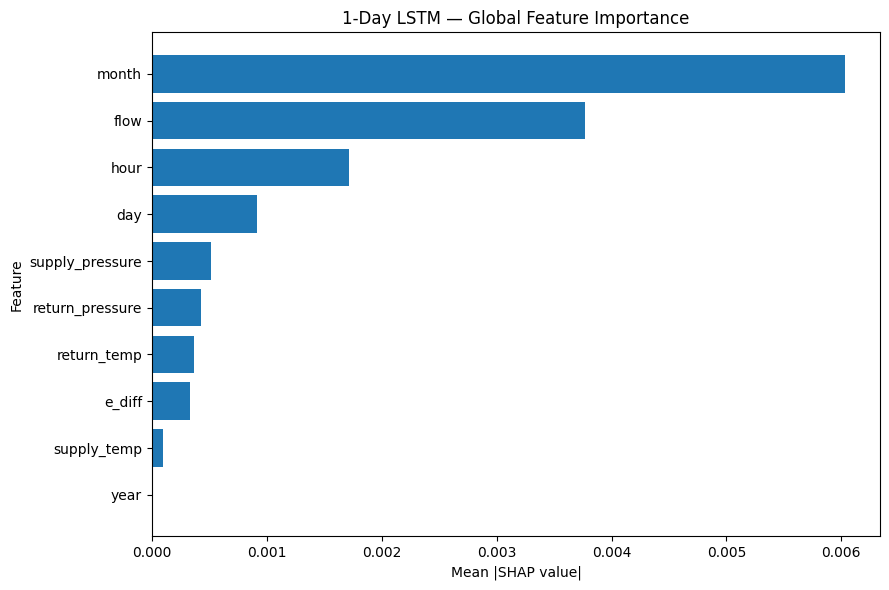

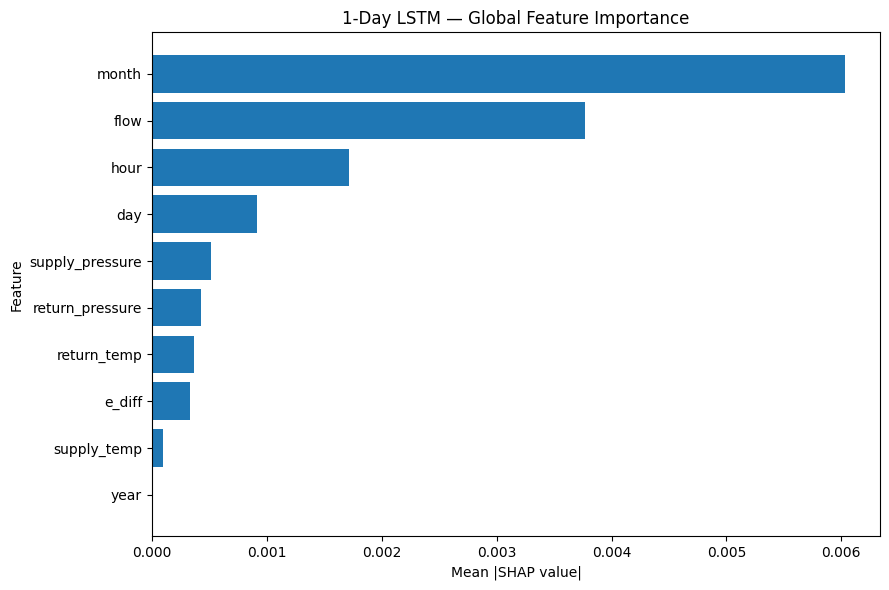

In [43]:
plot_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(
    "1-Day LSTM — Global Feature Importance"
)

plt.tight_layout()
plt.show()
plot_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(
    "1-Day LSTM — Global Feature Importance"
)

plt.tight_layout()
plt.show()

In [44]:
time_feature_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 3)
)

print(time_feature_importance.shape)

(24, 10)


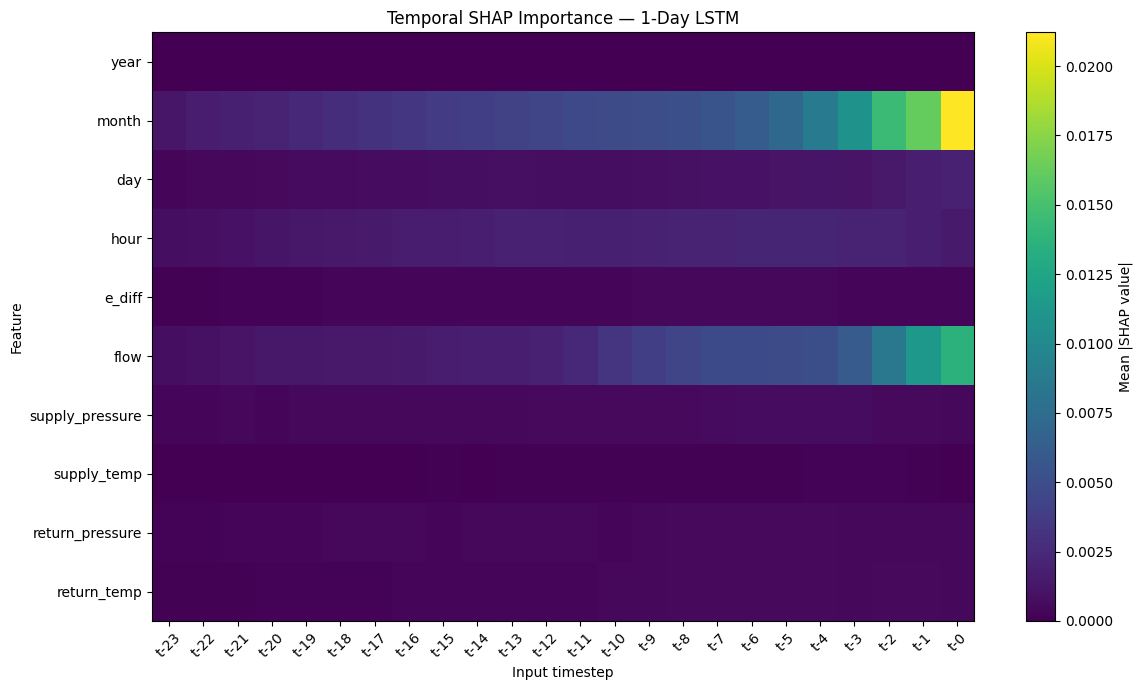

In [45]:
plt.figure(figsize=(12, 7))

plt.imshow(
    time_feature_importance.T,
    aspect="auto"
)

plt.colorbar(
    label="Mean |SHAP value|"
)

plt.yticks(
    np.arange(len(FEATURE_COLS)),
    FEATURE_COLS
)

plt.xticks(
    np.arange(24),
    [f"t-{23-i}" for i in range(24)],
    rotation=45
)

plt.xlabel("Input timestep")
plt.ylabel("Feature")

plt.title(
    "Temporal SHAP Importance — 1-Day LSTM"
)

plt.tight_layout()
plt.show()

In [46]:
RESULT_DIR ="/content/drive/MyDrive/paper1-reproduction-2022-2/results/chronological_split"

SHAP_RESULT_DIR = (
    f"{RESULT_DIR}/shap"
)

os.makedirs(
    SHAP_RESULT_DIR,
    exist_ok=True
)

shap_importance_df.to_csv(
    f"{SHAP_RESULT_DIR}/1day_feature_importance.csv",
    index=False
)

np.save(
    f"{SHAP_RESULT_DIR}/1day_shap_values.npy",
    shap_values
)

print("SHAP results saved.")

SHAP results saved.
